In [382]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import skew
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PowerTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

df=pd.read_csv('/content/Walmart Data Analysis and Forcasting.csv')

df["Date"] = pd.to_datetime(df["Date"],format="%d-%m-%Y")
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df=df.drop(columns=["Date"])

In [383]:
df.isnull().sum()

,0
Store,0
Weekly_Sales,0
Holiday_Flag,0
Temperature,0
Fuel_Price,0
CPI,0
Unemployment,0
Year,0
Month,0
Day,0


In [384]:
print("\nDataset description\n",df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Weekly_Sales  6435 non-null   float64
 2   Holiday_Flag  6435 non-null   int64  
 3   Temperature   6435 non-null   float64
 4   Fuel_Price    6435 non-null   float64
 5   CPI           6435 non-null   float64
 6   Unemployment  6435 non-null   float64
 7   Year          6435 non-null   int32  
 8   Month         6435 non-null   int32  
 9   Day           6435 non-null   int32  
dtypes: float64(5), int32(3), int64(2)
memory usage: 427.5 KB

Dataset description
 None


In [385]:
# Summary statistics
print("\nSummary Statistics:\n", df.describe())


Summary Statistics:
              Store  Weekly_Sales  Holiday_Flag  Temperature   Fuel_Price  \
count  6435.000000  6.435000e+03   6435.000000  6435.000000  6435.000000   
mean     23.000000  1.046965e+06      0.069930    60.663782     3.358607   
std      12.988182  5.643666e+05      0.255049    18.444933     0.459020   
min       1.000000  2.099862e+05      0.000000    -2.060000     2.472000   
25%      12.000000  5.533501e+05      0.000000    47.460000     2.933000   
50%      23.000000  9.607460e+05      0.000000    62.670000     3.445000   
75%      34.000000  1.420159e+06      0.000000    74.940000     3.735000   
max      45.000000  3.818686e+06      1.000000   100.140000     4.468000   

               CPI  Unemployment         Year        Month          Day  
count  6435.000000   6435.000000  6435.000000  6435.000000  6435.000000  
mean    171.578394      7.999151  2010.965035     6.447552    15.678322  
std      39.356712      1.875885     0.797019     3.238308     8.755780

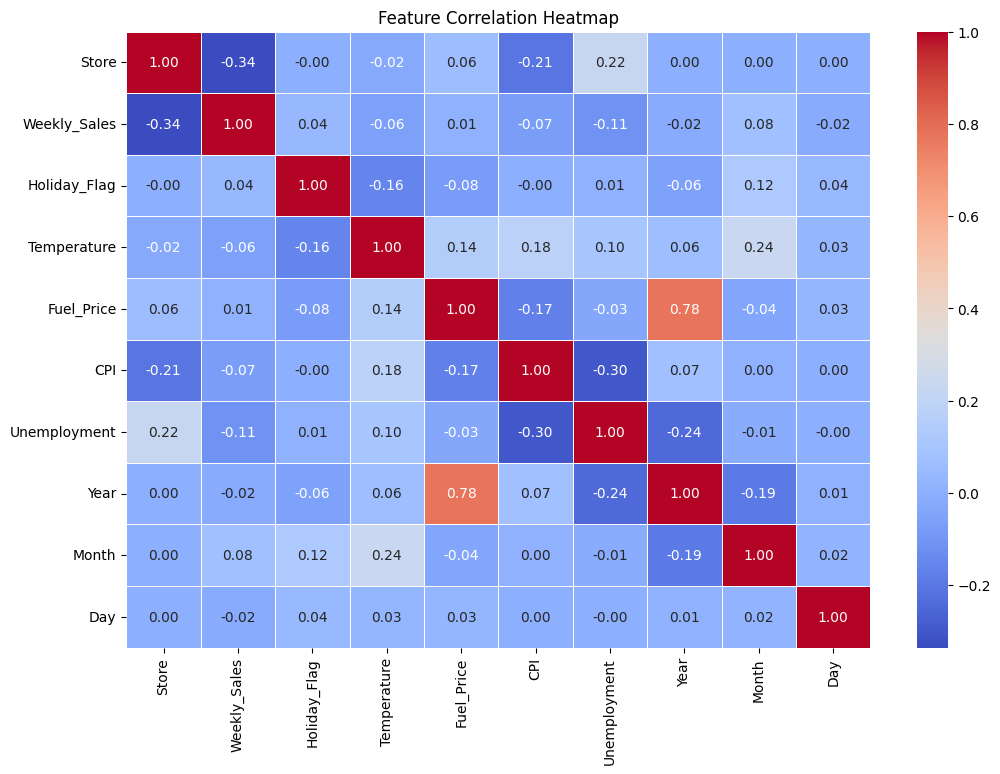

In [386]:
# Correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
# the annotation would show the correlation values for each pair of variables in your DataFrame.
#annot=True, you're asking the heatmap to display the actual numeric value inside each colored cell.
plt.title("Feature Correlation Heatmap")

plt.show()

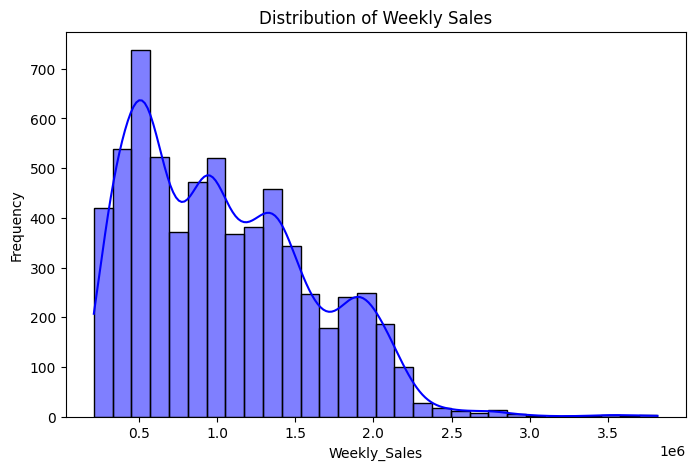

In [387]:
# Distribution of target variable (MEDV)
plt.figure(figsize=(8, 5))
sns.histplot(df['Weekly_Sales'], bins=30,kde=True,color='blue')
plt.title("Distribution of Weekly Sales")
plt.xlabel("Weekly_Sales")
plt.ylabel("Frequency")
plt.show()

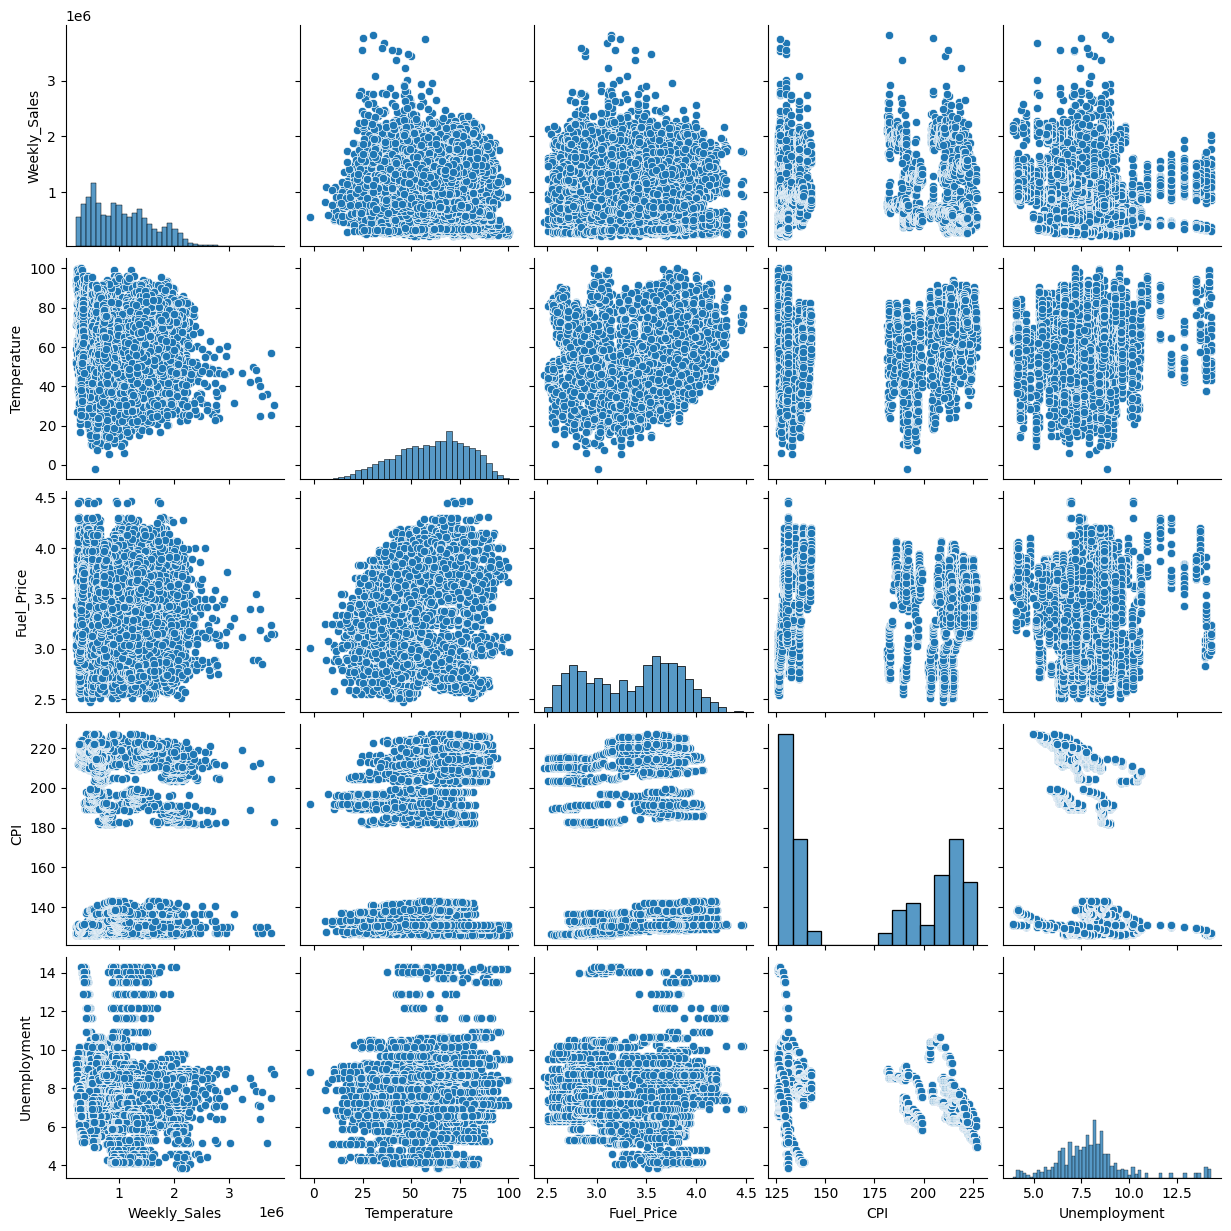

In [388]:
# Pairplot for key variables
sns.pairplot(df[['Weekly_Sales', 'Temperature', 'Fuel_Price','CPI','Unemployment']])
plt.show()

In [389]:
# Define features (X) and target (y)
X=df.drop(columns=["Weekly_Sales"])
y=df["Weekly_Sales"]

In [390]:
scaler=StandardScaler()
X=scaler.fit_transform(X)

In [391]:
# Split the dataset (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Model Evaluation
r2 = r2_score(y_test, y_pred)
#rmse = mean_squared_error(y_test, y_pred, squared=False)
rmse = mean_squared_error(y_test, y_pred) ** 0.5

print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

R² Score: 0.1555
RMSE: 521597.6144


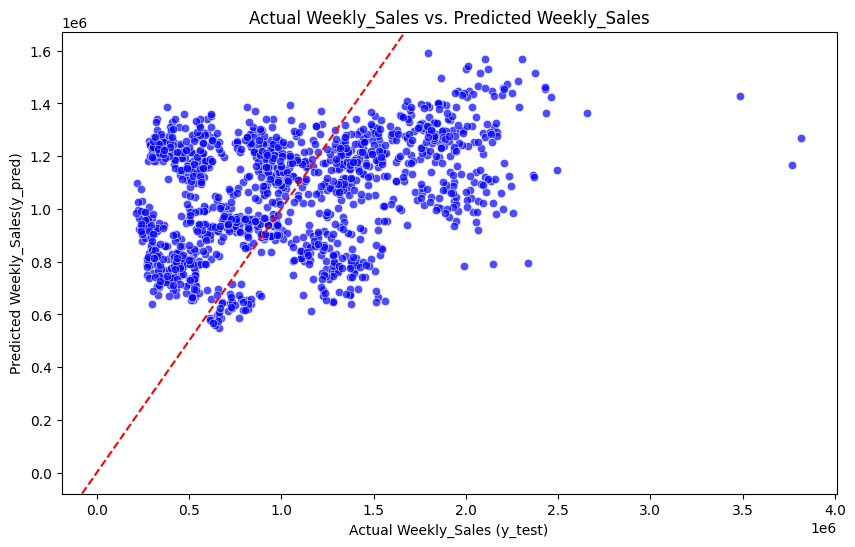

In [392]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred,color="blue",alpha=0.7)
plt.xlabel("Actual Weekly_Sales (y_test)")
plt.ylabel("Predicted Weekly_Sales(y_pred)")
plt.title("Actual Weekly_Sales vs. Predicted Weekly_Sales")
plt.axline([0,0],[1,1],color="red",linestyle="--")
plt.show()

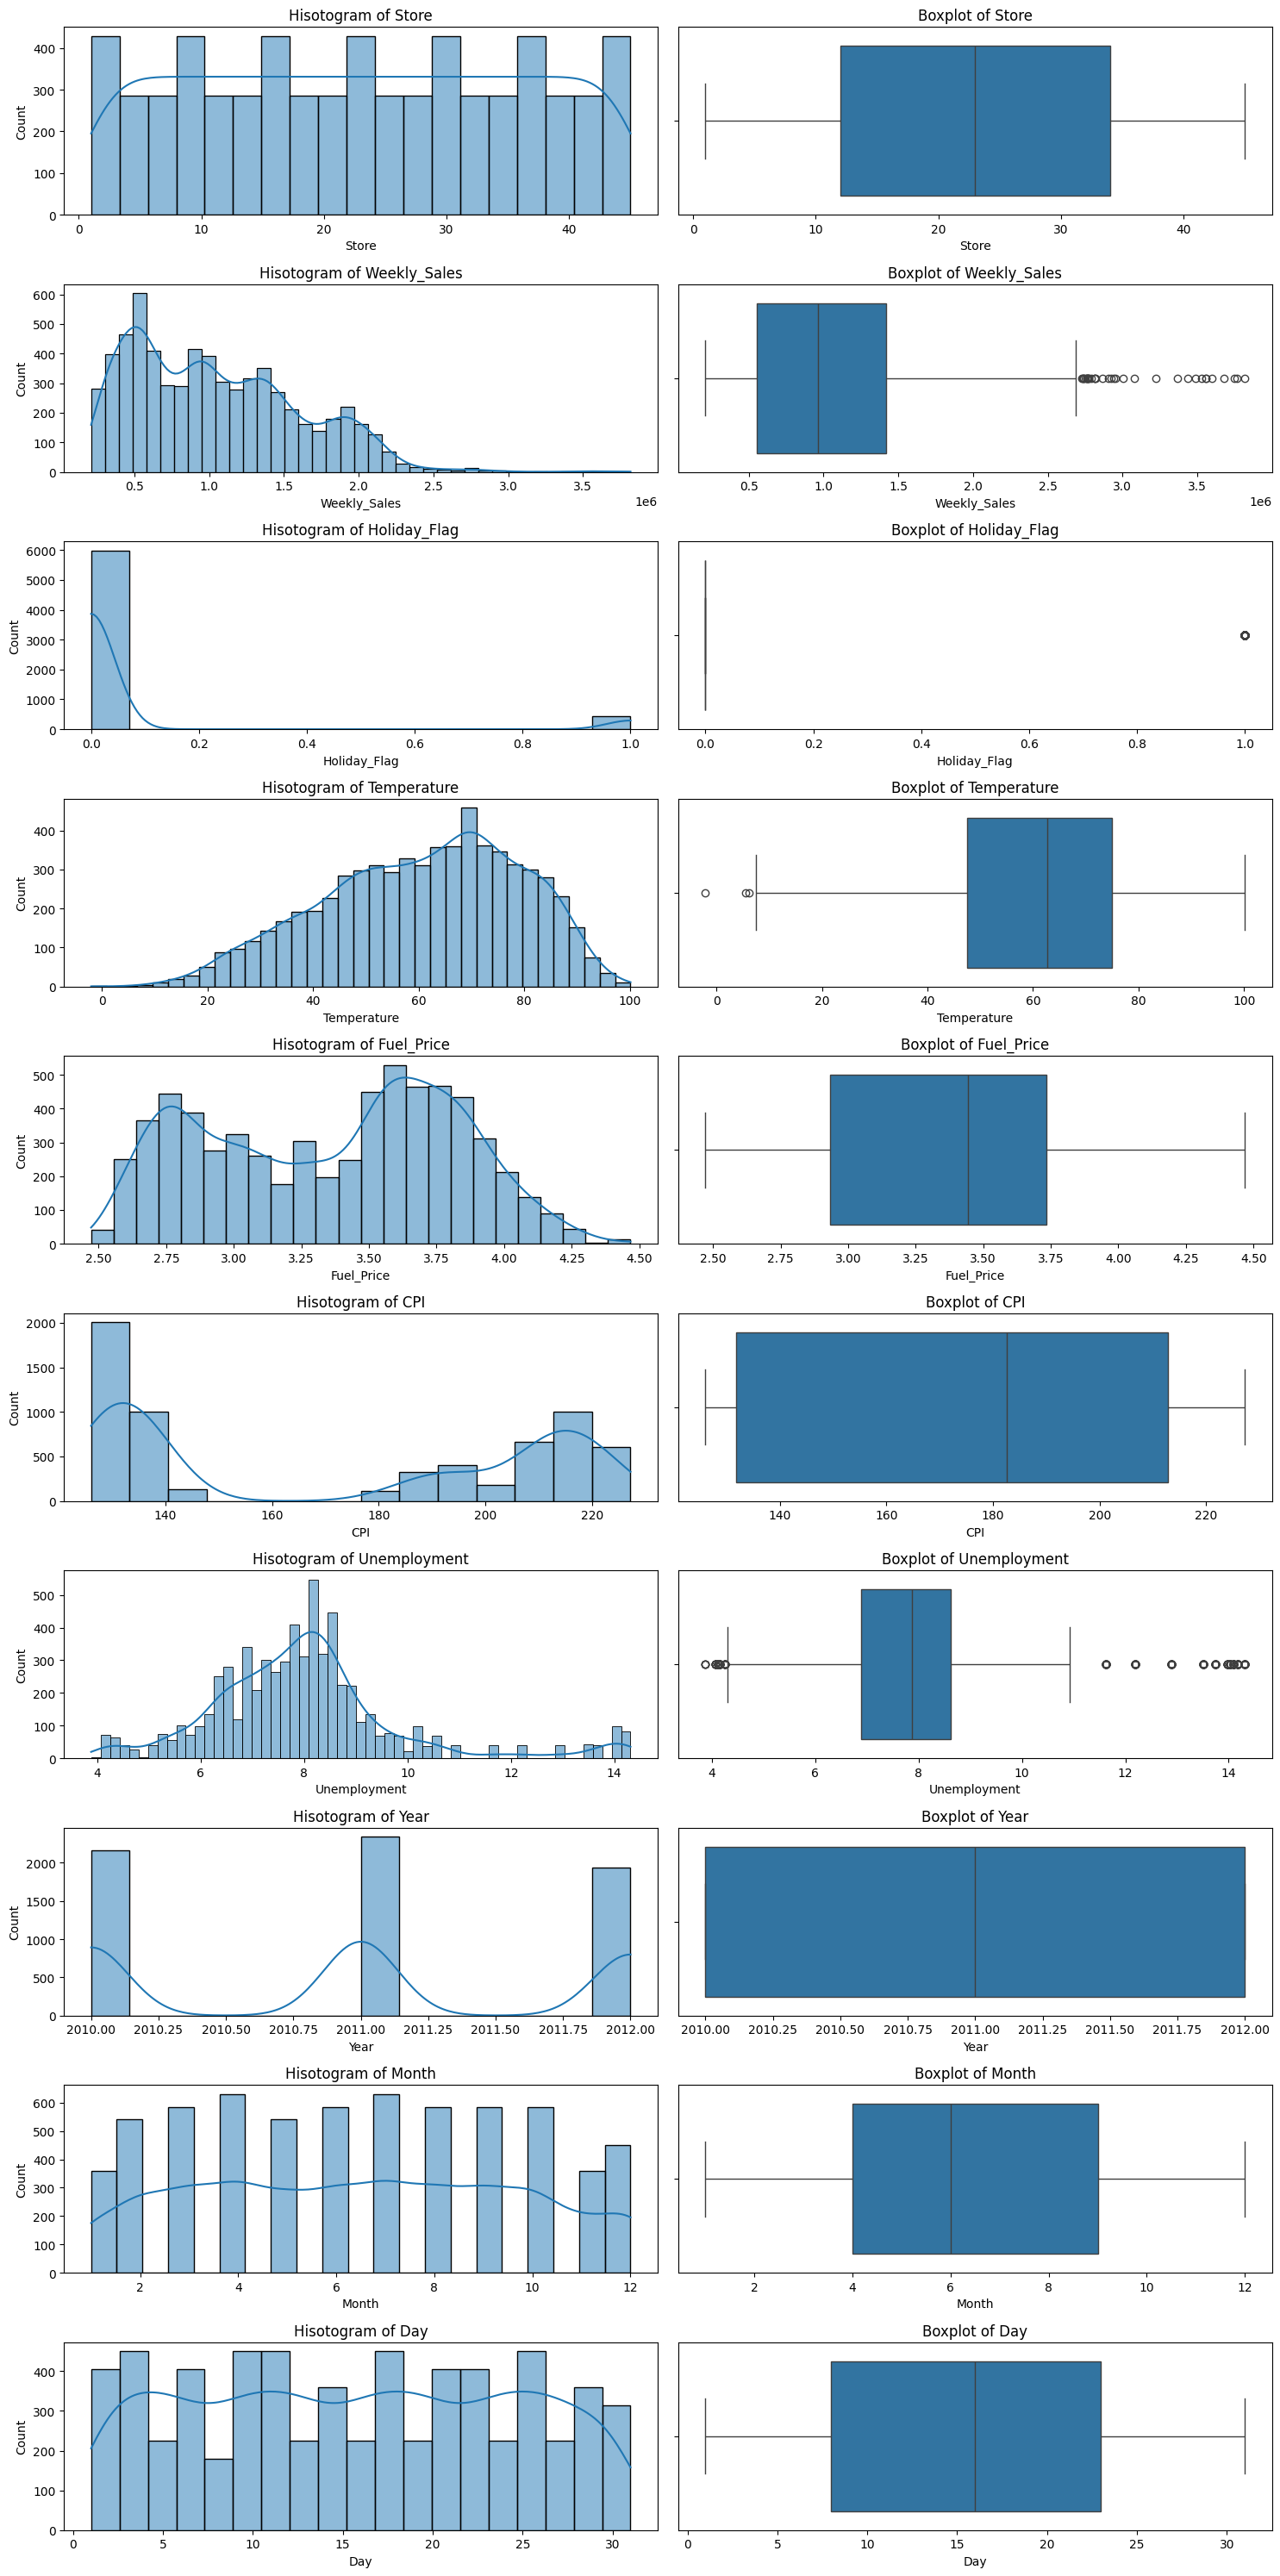

In [393]:
#Plot histograms and boxplots

num_cols=len(df.columns)
plt.figure(figsize=(15,num_cols*3))

for i,col in enumerate(df.columns):
  plt.subplot(num_cols,2,2*i+1)
  sns.histplot(df[col],kde=True)
  plt.title(f"Hisotogram of {col}")

  plt.subplot(num_cols,2,2*i+2)
  sns.boxplot(x=df[col])
  plt.title(f"Boxplot of {col}")

plt.tight_layout()
plt.show()

In [394]:
skewness=df.skew()
print(skewness)

Store           0.000000
Weekly_Sales    0.668362
Holiday_Flag    3.373499
Temperature    -0.336768
Fuel_Price     -0.096158
CPI             0.063492
Unemployment    1.188144
Year            0.062642
Month           0.039568
Day             0.008512
dtype: float64


In [395]:
skew_col=df.skew().abs()
high_skew=skew_col[skew_col>1].index
neg_skew=skew_col[skew_col<1].index
print("Highly skewed colums:\n",high_skew)
print("\nNegative skewed columns:\n",neg_skew)

Highly skewed colums:
 Index(['Holiday_Flag', 'Unemployment'], dtype='object')

Negative skewed columns:
 Index(['Store', 'Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI', 'Year',
       'Month', 'Day'],
      dtype='object')


In [396]:
#high skew transformation

df[high_skew]=df[high_skew].apply(lambda x: np.log1p(x))

#low skew transformation



pt=PowerTransformer(method='yeo-johnson')
df[neg_skew]=pt.fit_transform(df[neg_skew])

In [397]:
df.skew()

,0
Store,-0.228157
Weekly_Sales,-0.049912
Holiday_Flag,3.373499
Temperature,-0.141684
Fuel_Price,-0.055815
CPI,0.010477
Unemployment,0.226991
Year,0.000000
Month,-0.140278
Day,-0.209117


In [398]:
X=df.drop(columns=["Weekly_Sales"])
y=df["Weekly_Sales"]

# Split the dataset (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Model Evaluation
r2 = r2_score(y_test, y_pred)
#rmse = mean_squared_error(y_test, y_pred, squared=False)
rmse = mean_squared_error(y_test, y_pred) ** 0.5

print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

R² Score: 0.1336
RMSE: 0.9428


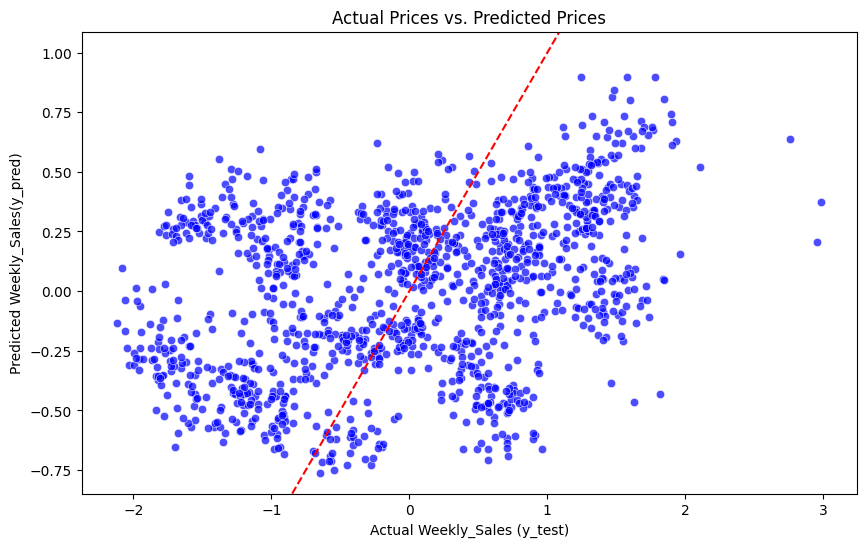

In [399]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred,color="blue",alpha=0.7)
plt.xlabel("Actual Weekly_Sales (y_test)")
plt.ylabel("Predicted Weekly_Sales(y_pred)")
plt.title("Actual Prices vs. Predicted Prices")
plt.axline([0,0],[1,1],color="red",linestyle="--")
plt.show()

In [400]:
#RANDOM FOREST REGRESSOR

#train Random Forest

rf_model=RandomForestRegressor(n_estimators=100,random_state=42)
rf_model.fit(X_train,y_train)

#predicts and evaluation

y_pred=rf_model.predict(X_test)
r2=r2_score(y_test,y_pred)
rmse=mean_squared_error(y_test,y_pred)**0.5

print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

R² Score: 0.9762
RMSE: 0.1563


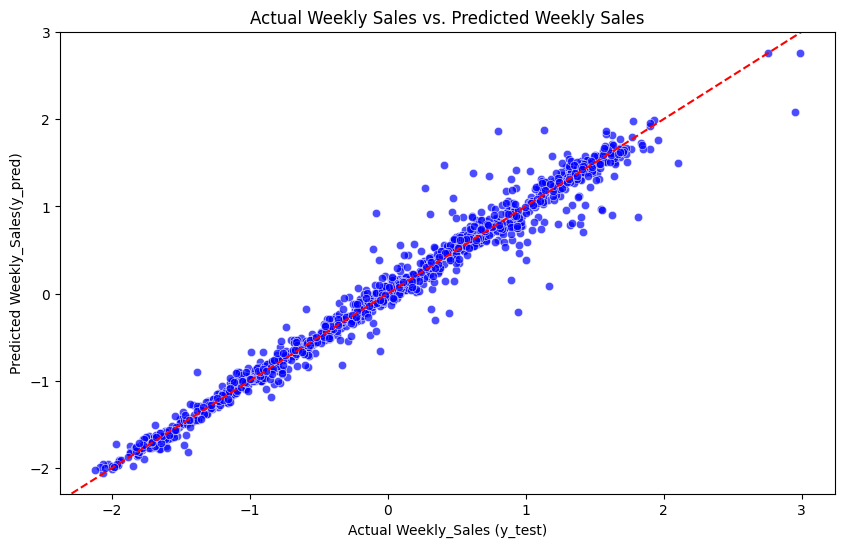

In [402]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred,color="blue",alpha=0.7)
plt.xlabel("Actual Weekly_Sales (y_test)")
plt.ylabel("Predicted Weekly_Sales(y_pred)")
plt.title("Actual Weekly Sales vs. Predicted Weekly Sales")
plt.axline([0,0],[1,1],color="red",linestyle="--")
plt.show()